# TTC Transformer â€” Visual Validation

Run this notebook **after** training (`python -m transformer.train`).

Outputs:
- **Frame gallery** â€” actual robot frames with GT vs predicted TTC overlaid
- **Countdown curves** â€” predicted vs actual TTC over time per episode
- **Per-episode RÂ²/MAE bar chart**

All plots saved to `output/transformer/plots/`.

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import yaml
from sklearn.metrics import r2_score, mean_absolute_error

import sys
sys.path.insert(0, str(Path(".").resolve().parent))  # repo root
from transformer.model import CausalTTCTransformer

# â”€â”€ Config â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
CKPT_PATH  = Path("../output/transformer_cubetobox_k32_sparse/best_model.pt")
FEAT_CACHE = Path("../output/cube-to-box/dino_features.npz")
HDF5_PATH  = Path("../output/hdf5/cube-to-box/dataset.h5")
CFG_PATH   = Path("configs/config.yaml")
CAMERA     = "head_left"
N_FRAMES   = 6      # frames shown per episode in the gallery
USE_WANDB  = False
WANDB_RUN_ID = None  # paste your run id here to resume an existing run

PLOT_DIR = Path("../output/transformer_cubetobox_k32_sparse/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## 1 Load model + feature cache

The checkpoint contains both the trained weights and the config used to create the model, so we can reconstruct it exactly without re-specifying architecture parameters.

In [2]:
# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
cfg  = ckpt["cfg"]
K    = cfg["window_size"]

model = CausalTTCTransformer(
    d_input  = cfg["d_input"],
    d_model  = cfg["d_model"],
    n_heads  = cfg["n_heads"],
    n_layers = cfg["n_layers"],
    d_ff     = cfg["d_ff"],
    dropout  = 0.0,   # eval mode â€” no dropout
    K        = K,
).to(DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded checkpoint  epoch={ckpt['epoch']}  val_RÂ²={ckpt['val_r2']:.3f}")
print(f"Window size K = {K} frames  ({K/50:.2f} s at 50 fps)")

# Load feature cache
# dino_features.npz was produced by ttc_sanity.ipynb:
#   DINO-v2 was run once on every frame â†’ 768-d [CLS] vectors saved to disk.
#   episode_ids maps each row back to its source episode.
cache       = np.load(FEAT_CACHE)
features    = cache["features"]     # (N, 768)
ttc_s       = cache["ttc_s"]        # (N,) ground-truth seconds to episode end
episode_ids = cache["episode_ids"]  # (N,) integer episode index
n_ep        = int(episode_ids.max()) + 1
print(f"Feature cache: {len(features):,} frames  {n_ep} episodes")

# Derive test episode set (same logic as make_splits)
with h5py.File(HDF5_PATH, "r") as f:
    ep_keys = sorted(k for k in f.keys() if k.startswith("episode_"))

excluded: set[int] = set()
for name in cfg.get("excluded_episodes", []):
    if name in ep_keys:
        excluded.add(ep_keys.index(name))

n_test   = max(1, round(n_ep * cfg["test_fraction"]))
test_eps = sorted(set(range(n_ep - n_test, n_ep)) - excluded)
print(f"Test episodes : {[ep_keys[i] for i in test_eps]}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\output\\transformer_cubetobox_k32_sparse\\best_model.pt'

## 2 Full-episode inference

For each frame at position `i` (from Kâˆ’1 onward), we take the window of K consecutive feature vectors ending at `i` and pass it through the transformer.

The first Kâˆ’1 frames of every episode have **no prediction** â€” the window isn't full yet.  
At 50 fps with K=32, this is a 0.64-second warmup at the start of each episode.

In [ ]:
def predict_episode(ep_idx: int):
    """Run the transformer over one episode. Returns (gt_s, pred_s), both shape (N,).
    Frames 0..K-2 have pred_s = NaN (warmup period).
    """
    ep_mask  = episode_ids == ep_idx
    ep_feats = features[ep_mask].astype(np.float32)  # (N, 768)
    ep_ttc   = ttc_s[ep_mask]                        # (N,) ground truth
    n = len(ep_feats)

    pred_log = np.full(n, np.nan, dtype=np.float32)

    # Batch inference for speed: build all valid windows at once
    if n >= K:
        windows = np.stack(
            [ep_feats[i - K + 1 : i + 1] for i in range(K - 1, n)], axis=0
        )  # (n - K + 1, K, 768)
        t = torch.from_numpy(windows).to(DEVICE)
        with torch.no_grad():
            out = model(t).cpu().numpy()   # (n - K + 1,)
        pred_log[K - 1:] = out

    pred_s = np.expm1(pred_log).clip(0)   # back to seconds; NaN stays NaN
    return ep_ttc, pred_s


# Run inference on all test episodes and cache results
ep_results = {}   # ep_idx â†’ (gt_s, pred_s)
for ep_idx in test_eps:
    gt, pred = predict_episode(ep_idx)
    ep_results[ep_idx] = (gt, pred)
    valid = ~np.isnan(pred)
    if valid.any():
        r2  = r2_score(np.log1p(gt[valid]), np.log1p(pred[valid]))
        mae = mean_absolute_error(gt[valid], pred[valid])
        print(f"  {ep_keys[ep_idx]}  RÂ²={r2:.3f}  MAE={mae:.2f}s  "
              f"({valid.sum()}/{len(gt)} frames with predictions)")

  episode_000038  RÂ²=0.814  MAE=1.87s  (717/748 frames with predictions)
  episode_000039  RÂ²=0.317  MAE=2.41s  (714/745 frames with predictions)
  episode_000040  RÂ²=0.480  MAE=1.24s  (699/730 frames with predictions)
  episode_000041  RÂ²=0.896  MAE=0.89s  (597/628 frames with predictions)
  episode_000042  RÂ²=0.835  MAE=0.63s  (585/616 frames with predictions)
  episode_000043  RÂ²=0.788  MAE=0.89s  (547/578 frames with predictions)
  episode_000045  RÂ²=0.581  MAE=1.16s  (613/644 frames with predictions)


## 3 Â· Frame gallery

For each test episode, N evenly-spaced frames are shown with GT and predicted TTC overlaid.  
Border colour indicates prediction quality: green < 2 s error, orange < 5 s, red â‰¥ 5 s.

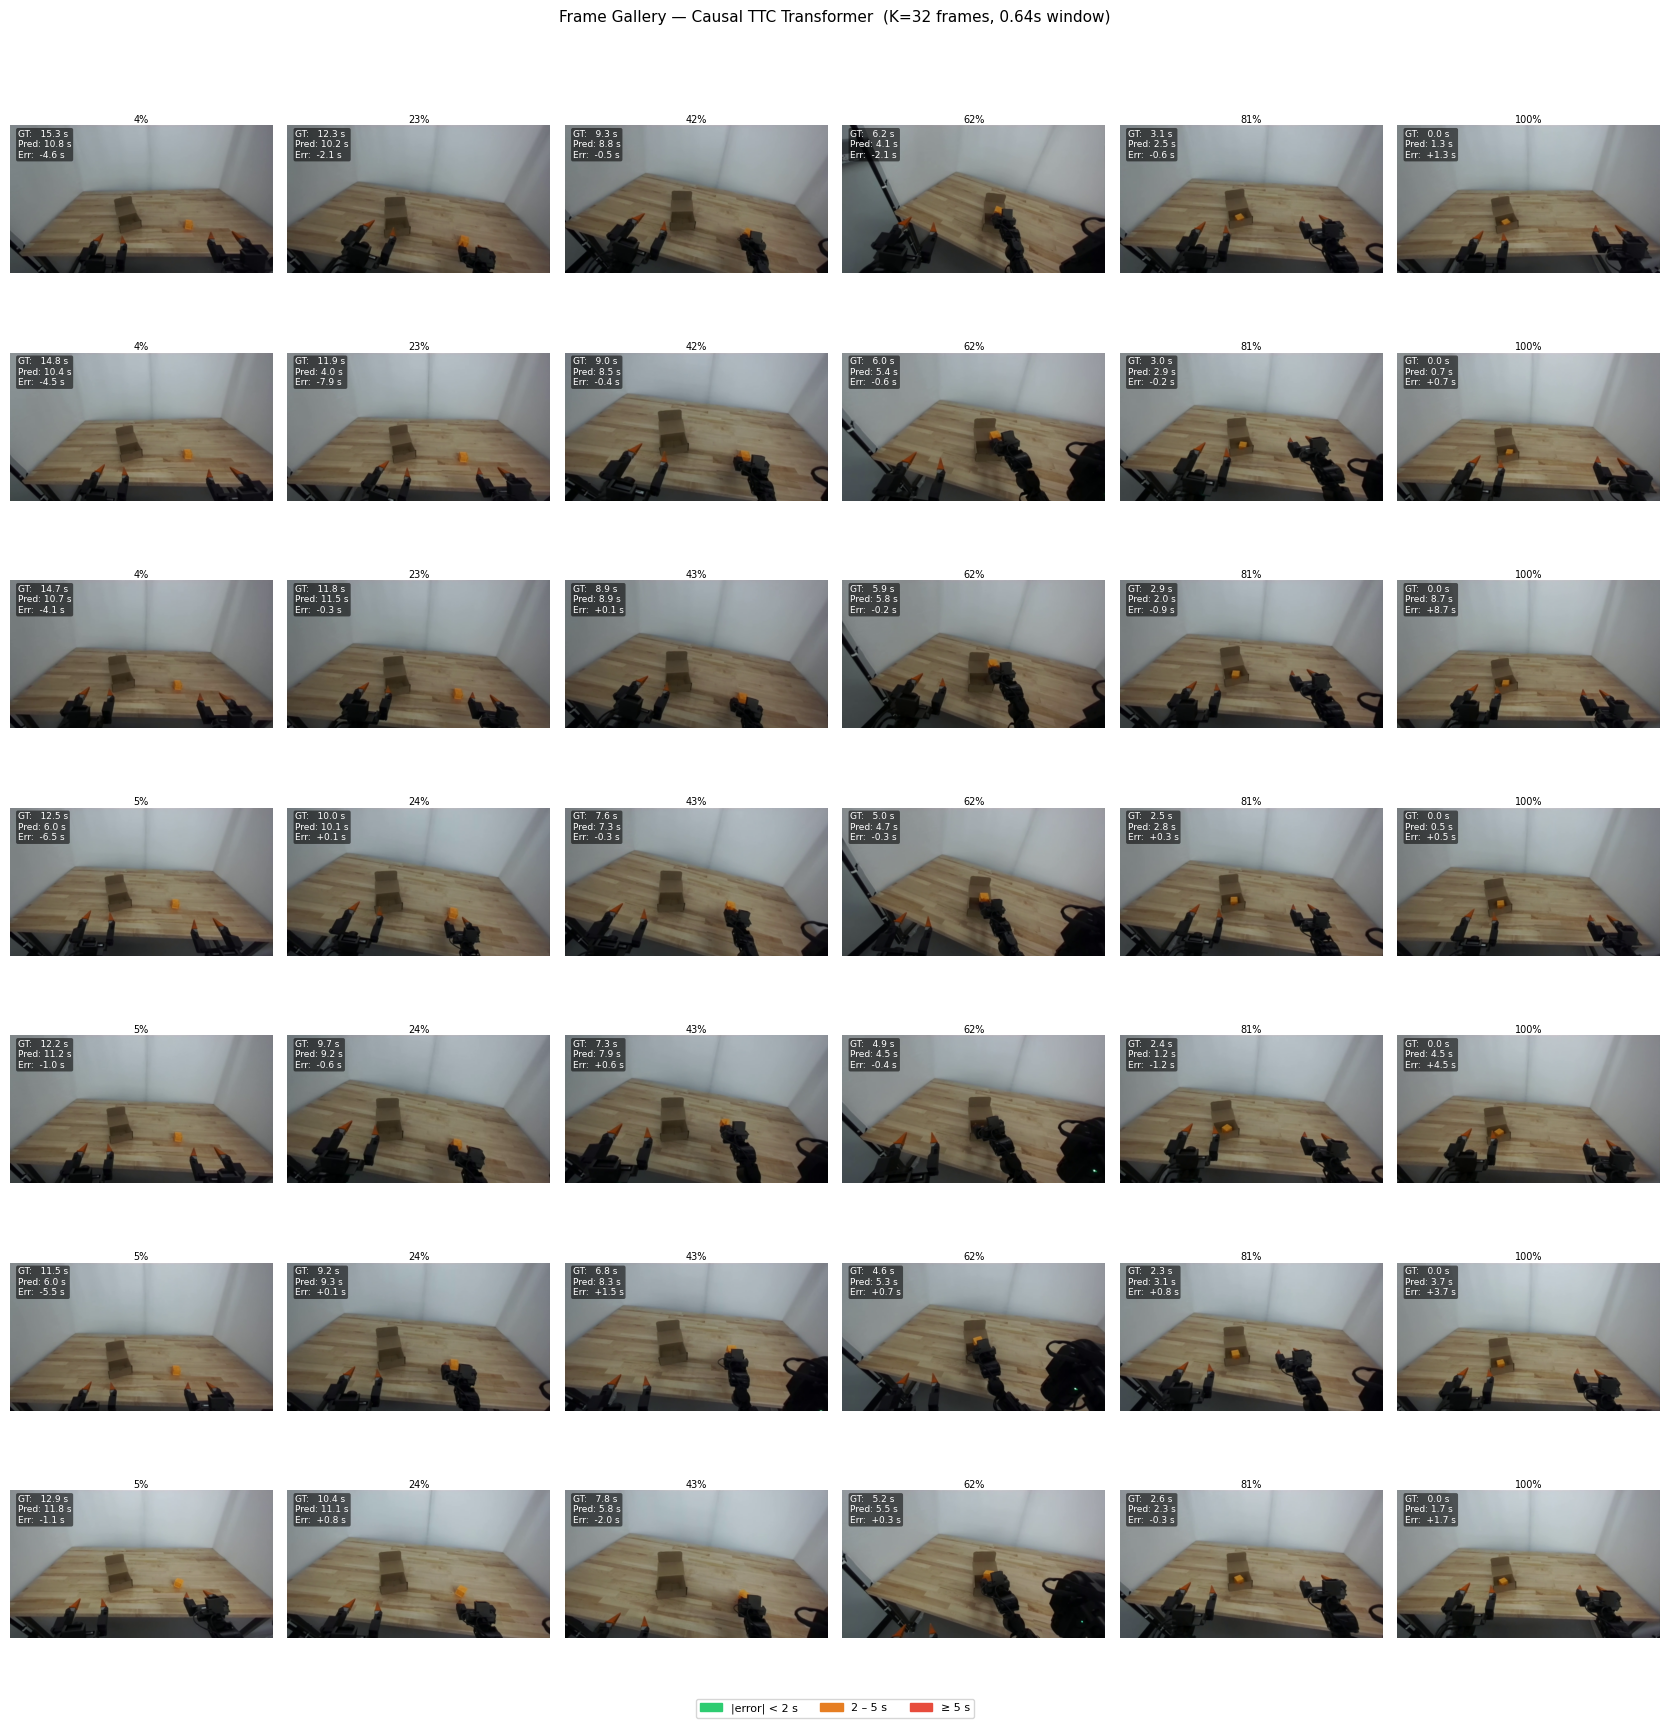

Saved â†’ ..\output\transformer\plots\frame_gallery.png


In [ ]:
def error_colour(err_s: float) -> str:
    e = abs(err_s)
    if e < 2.0:  return "#2ecc71"   # green
    if e < 5.0:  return "#e67e22"   # orange
    return           "#e74c3c"       # red


n_rows = len(test_eps)
fig, axes = plt.subplots(
    n_rows, N_FRAMES,
    figsize=(N_FRAMES * 2.8, n_rows * 2.4),
    squeeze=False,
)

with h5py.File(HDF5_PATH, "r") as f:
    for row, ep_idx in enumerate(test_eps):
        ep_key = ep_keys[ep_idx]
        ep     = f[ep_key]

        gt_s, pred_s = ep_results[ep_idx]
        n = len(gt_s)

        # Load all frames for this episode
        if CAMERA not in ep.get("cameras", {}):
            for ax in axes[row]:
                ax.axis("off")
                ax.set_title(f"{ep_key}\ncamera not found", fontsize=7)
            continue

        frames = ep["cameras"][CAMERA][:]   # (N, H, W, 3) uint8

        # Sample N frames from the region where predictions exist (frame K-1 onward)
        valid_start = K - 1
        indices = np.linspace(valid_start, n - 1, N_FRAMES, dtype=int)

        for col, fi in enumerate(indices):
            ax = axes[row][col]
            ax.imshow(frames[fi])
            ax.axis("off")

            gt   = float(gt_s[fi])
            pred = float(pred_s[fi]) if not np.isnan(pred_s[fi]) else None
            err  = (pred - gt) if pred is not None else None

            # Text overlay
            txt = f"GT:   {gt:.1f} s"
            if pred is not None:
                txt += f"\nPred: {pred:.1f} s"
                txt += f"\nErr:  {err:+.1f} s"
            col_txt = error_colour(err) if err is not None else "gray"

            ax.text(
                0.03, 0.97, txt,
                transform=ax.transAxes,
                fontsize=6.5, color="white", va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.55, lw=0),
            )

            # Coloured border
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color(col_txt)
                spine.set_linewidth(3)

            if col == 0:
                ax.set_ylabel(ep_key, fontsize=7, rotation=0,
                              labelpad=80, va="center")

            # Progress label on top
            pct = 100 * fi / max(n - 1, 1)
            ax.set_title(f"{pct:.0f}%", fontsize=7, pad=2)

fig.suptitle(
    f"Frame Gallery â€” Causal TTC Transformer  (K={K} frames, {K/50:.2f}s window)",
    fontsize=11, y=1.01,
)

# Legend
legend_patches = [
    mpatches.Patch(color="#2ecc71", label="|error| < 2 s"),
    mpatches.Patch(color="#e67e22", label="2 â€“ 5 s"),
    mpatches.Patch(color="#e74c3c", label="â‰¥ 5 s"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
gallery_path = PLOT_DIR / "frame_gallery.png"
fig.savefig(gallery_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {gallery_path}")

## 4 Â· TTC countdown curves

Predicted (dashed red) vs actual (solid blue) TTC over time for each test episode.  
Grey shading = Kâˆ’1 warmup frames with no prediction.

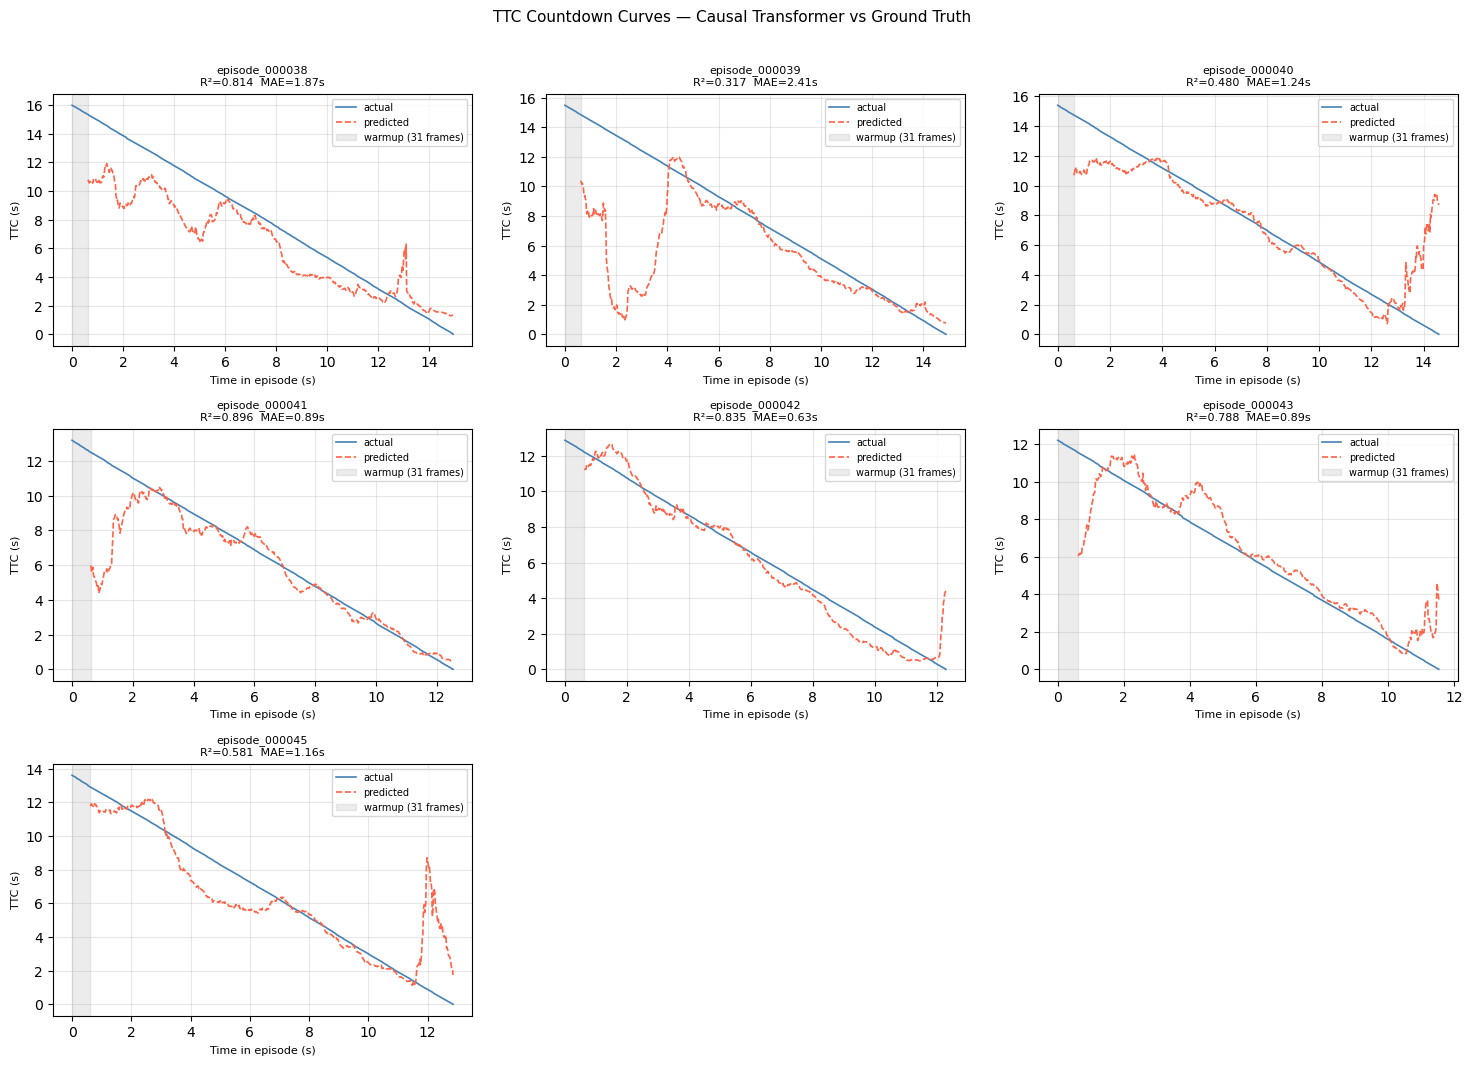

Saved â†’ ..\output\transformer\plots\episode_curves.png


In [ ]:
n_cols = min(3, len(test_eps))
n_rows = (len(test_eps) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 3.5),
                         squeeze=False)

for idx, ep_idx in enumerate(test_eps):
    ax  = axes[idx // n_cols][idx % n_cols]
    gt, pred = ep_results[ep_idx]
    t   = np.arange(len(gt)) / 50.0   # seconds along episode timeline

    ax.plot(t, gt,   color="steelblue", lw=1.2, label="actual")
    ax.plot(t, pred, color="tomato",    lw=1.2, ls="--", label="predicted")

    # Shade warmup region
    warmup_end = (K - 1) / 50.0
    ax.axvspan(0, warmup_end, color="gray", alpha=0.15, label=f"warmup ({K-1} frames)")

    valid = ~np.isnan(pred)
    if valid.any():
        r2  = r2_score(np.log1p(gt[valid]), np.log1p(pred[valid]))
        mae = mean_absolute_error(gt[valid], pred[valid])
        ax.set_title(f"{ep_keys[ep_idx]}\nRÂ²={r2:.3f}  MAE={mae:.2f}s", fontsize=8)
    else:
        ax.set_title(ep_keys[ep_idx], fontsize=8)

    ax.set_xlabel("Time in episode (s)", fontsize=8)
    ax.set_ylabel("TTC (s)", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(test_eps), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

plt.suptitle("TTC Countdown Curves â€” Causal Transformer vs Ground Truth",
             fontsize=11, y=1.01)
plt.tight_layout()
curves_path = PLOT_DIR / "episode_curves.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved â†’ {curves_path}")

## 5 Â· Per-episode RÂ² and MAE summary

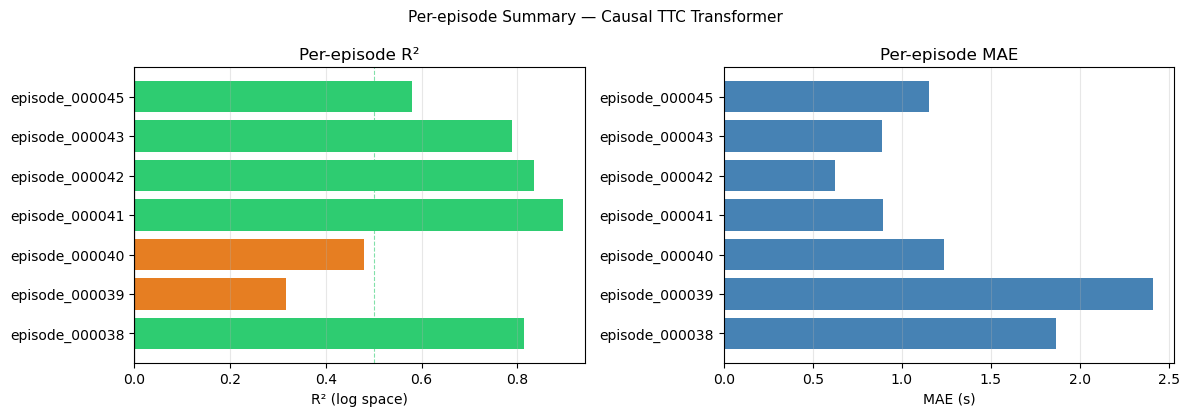

episode                 RÂ² (log)   MAE (s)  n_frames   TTC max
--------------------------------------------------------------
episode_000038             0.814      1.87       717      16.0
episode_000039             0.317      2.41       714      15.5
episode_000040             0.480      1.24       699      15.4
episode_000041             0.896      0.89       597      13.2
episode_000042             0.835      0.63       585      12.9
episode_000043             0.788      0.89       547      12.2
episode_000045             0.581      1.16       613      13.6
Saved â†’ ..\output\transformer\plots\per_episode_r2.png


In [ ]:
rows = []
for ep_idx in test_eps:
    gt, pred = ep_results[ep_idx]
    valid = ~np.isnan(pred)
    if not valid.any():
        continue
    r2  = r2_score(np.log1p(gt[valid]), np.log1p(pred[valid]))
    mae = mean_absolute_error(gt[valid], pred[valid])
    rows.append(dict(episode=ep_keys[ep_idx], r2=r2, mae=mae,
                     n_frames=int(valid.sum()), ttc_max=float(gt.max())))

labels = [r["episode"] for r in rows]
r2s    = [r["r2"]      for r in rows]
maes   = [r["mae"]     for r in rows]
colors = ["#2ecc71" if v > 0.5 else "#e67e22" if v > 0.2 else "#e74c3c" for v in r2s]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, max(3, len(rows) * 0.6)))

ax1.barh(labels, r2s, color=colors)
ax1.axvline(0, color="k", lw=0.8)
ax1.axvline(0.5, color="#2ecc71", lw=0.8, ls="--", alpha=0.6)
ax1.set_xlabel("RÂ² (log space)")
ax1.set_title("Per-episode RÂ²")
ax1.grid(True, axis="x", alpha=0.3)

ax2.barh(labels, maes, color="steelblue")
ax2.set_xlabel("MAE (s)")
ax2.set_title("Per-episode MAE")
ax2.grid(True, axis="x", alpha=0.3)

plt.suptitle("Per-episode Summary â€” Causal TTC Transformer", fontsize=11)
plt.tight_layout()
summary_path = PLOT_DIR / "per_episode_r2.png"
fig.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

# Print table
print(f"{'episode':<22} {'RÂ² (log)':>9} {'MAE (s)':>9} {'n_frames':>9} {'TTC max':>9}")
print("-" * 62)
for r in rows:
    print(f"{r['episode']:<22} {r['r2']:>9.3f} {r['mae']:>9.2f} "
          f"{r['n_frames']:>9} {r['ttc_max']:>9.1f}")
print(f"Saved â†’ {summary_path}")

## 6 Â· Optional W&B logging

Set `USE_WANDB = True` in cell 1 and optionally set `WANDB_RUN_ID` to attach these plots to an existing training run.

In [ ]:
if USE_WANDB:
    import wandb
    wandb.init(
        project = cfg["wandb_project"],
        entity  = cfg.get("wandb_entity") or None,
        id      = WANDB_RUN_ID,
        resume  = "allow" if WANDB_RUN_ID else None,
        config  = cfg,
    )
    wandb.log({
        "viz/frame_gallery":  wandb.Image(str(gallery_path)),
        "viz/episode_curves": wandb.Image(str(curves_path)),
        "viz/per_episode_r2": wandb.Image(str(summary_path)),
        **{f"test/{r['episode']}_r2":  r["r2"]  for r in rows},
        **{f"test/{r['episode']}_mae": r["mae"] for r in rows},
    })
    wandb.finish()
    print("W&B run updated.")
else:
    print("W&B logging disabled. Set USE_WANDB = True in cell 1 to enable.")

W&B logging disabled. Set USE_WANDB = True in cell 1 to enable.


## 7b Â· Side-by-side video export (camera feed + live TTC graph)

For each frame: left panel = robot camera image, right panel = TTC graph with the curve populating in real time and a vertical marker at the current position.

Output:
- **`.npy`** â€” raw numpy array `(T, H, W*2, 3)` uint8, ready for any encoder
- **`.mp4`** â€” if `imageio[ffmpeg]` is installed (`pip install imageio[ffmpeg]`)

Change `VIDEO_EP_IDX` to any episode in `test_eps` to render a different episode.

In [ ]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
from PIL import Image as _PILImage

VIDEO_EP_IDX = test_eps[0]   # which test episode to render
VIDEO_FPS    = 15             # output frame rate (original is 50 fps)
VIDEO_HEIGHT = 360            # pixel height of each panel
VIDEO_DPI    = 100


def _fig_to_rgb(fig) -> np.ndarray:
    """Render a matplotlib figure to an (H, W, 3) uint8 array."""
    canvas = FigureCanvasAgg(fig)
    canvas.draw()
    w, h = canvas.get_width_height()
    buf = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    return buf[:, :, :3].copy()


def _render_graph(t_all: np.ndarray, gt: np.ndarray, pred: np.ndarray,
                  frame_idx: int, warmup_frames: int,
                  height: int = VIDEO_HEIGHT, dpi: int = VIDEO_DPI) -> np.ndarray:
    """Render the live TTC graph up to frame_idx. Returns (H, W, 3) uint8."""
    h_in = height / dpi
    fig, ax = plt.subplots(figsize=(h_in * 2, h_in), dpi=dpi)
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")

    t_now = t_all[frame_idx]
    warmup_end = warmup_frames / 50.0

    # Dim ghost of the full curves (future not yet revealed)
    ax.plot(t_all, gt,   color="#1f4e79", lw=1.0, alpha=0.25)
    ax.plot(t_all, pred, color="#7b2c2c", lw=1.0, alpha=0.25, ls="--")

    # Populated portion up to current frame
    ax.plot(t_all[:frame_idx + 1], gt[:frame_idx + 1],
            color="steelblue", lw=1.6, label="actual")
    valid_mask = ~np.isnan(pred[:frame_idx + 1])
    if valid_mask.any():
        idx_range = np.where(valid_mask)[0]
        ax.plot(t_all[idx_range], pred[idx_range],
                color="tomato", lw=1.6, ls="--", label="predicted")

    # Current-position dots
    ax.scatter([t_now], [gt[frame_idx]], color="steelblue", s=45, zorder=6)
    if not np.isnan(pred[frame_idx]):
        ax.scatter([t_now], [pred[frame_idx]], color="tomato", s=45, zorder=6)

    # Vertical "now" line
    ax.axvline(t_now, color="white", lw=0.8, alpha=0.45, zorder=5)

    # Warmup shading
    if warmup_end < t_all[-1]:
        ax.axvspan(0, min(warmup_end, t_now), color="gray", alpha=0.15)

    ax.set_xlim(0, t_all[-1])
    ax.set_ylim(-0.3, float(gt.max()) * 1.10)
    ax.set_xlabel("Time in episode (s)", fontsize=7, color="#aaaaaa")
    ax.set_ylabel("TTC (s)", fontsize=7, color="#aaaaaa")
    ax.tick_params(colors="#888888", labelsize=6)
    for spine in ax.spines.values():
        spine.set_color("#333333")
    ax.grid(True, alpha=0.12, color="#444444")
    ax.legend(fontsize=6, loc="upper right", labelcolor="white",
              facecolor="#1a1a1a", edgecolor="#444444")

    # Live annotation box
    if not np.isnan(pred[frame_idx]):
        err = pred[frame_idx] - gt[frame_idx]
        label = (f"GT:   {gt[frame_idx]:.1f} s\n"
                 f"Pred: {pred[frame_idx]:.1f} s\n"
                 f"Err:  {err:+.1f} s")
        ax.text(0.97, 0.97, label, transform=ax.transAxes, fontsize=7,
                color="white", va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a1a", alpha=0.75, lw=0))

    fig.tight_layout(pad=0.4)
    img = _fig_to_rgb(fig)
    plt.close(fig)
    return img


# â”€â”€ Build composite frames â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ep_idx  = VIDEO_EP_IDX
ep_key  = ep_keys[ep_idx]
gt_vid, pred_vid = ep_results[ep_idx]
t_all   = np.arange(len(gt_vid)) / 50.0

with h5py.File(HDF5_PATH, "r") as f:
    cam_frames = f[ep_key]["cameras"][CAMERA][:]   # (N, H, W, 3) uint8

step          = max(1, round(50 / VIDEO_FPS))
frame_indices = list(range(0, len(gt_vid), step))

print(f"Rendering {len(frame_indices)} frames for {ep_key}  "
      f"({len(frame_indices)/VIDEO_FPS:.1f} s at {VIDEO_FPS} fps) â€¦")

video_frames = []
for fi in frame_indices:
    # --- Camera panel ---
    cam = cam_frames[fi]                              # (H, W, 3)
    h, w = cam.shape[:2]
    cam_panel = np.array(
        _PILImage.fromarray(cam).resize(
            (round(w * VIDEO_HEIGHT / h), VIDEO_HEIGHT),
            _PILImage.BILINEAR,
        )
    )

    # --- Graph panel ---
    graph_panel = _render_graph(t_all, gt_vid, pred_vid, fi, warmup_frames=K - 1)
    gh, gw = graph_panel.shape[:2]
    if gh != VIDEO_HEIGHT:
        graph_panel = np.array(
            _PILImage.fromarray(graph_panel).resize(
                (round(gw * VIDEO_HEIGHT / gh), VIDEO_HEIGHT),
                _PILImage.BILINEAR,
            )
        )

    # --- Combine ---
    composite = np.concatenate([cam_panel, graph_panel], axis=1)
    video_frames.append(composite)

video_np = np.stack(video_frames, axis=0)   # (T, H, W_total, 3)
print(f"Video array: {video_np.shape}  dtype={video_np.dtype}")

# Save numpy array (always)
npy_path = PLOT_DIR / f"{ep_key}_ttc_video.npy"
np.save(npy_path, video_np)
print(f"Saved numpy â†’ {npy_path}")

# Save MP4 (optional â€” requires imageio[ffmpeg])
try:
    import imageio
    mp4_path = PLOT_DIR / f"{ep_key}_ttc_video.mp4"
    imageio.mimwrite(str(mp4_path), video_np, fps=VIDEO_FPS, quality=7,
                     output_params=["-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2"])
    print(f"Saved MP4  â†’ {mp4_path}")
except ImportError:
    print("MP4 skipped â€” install imageio[ffmpeg] to enable: pip install imageio[ffmpeg]")
except Exception as e:
    print(f"MP4 export failed ({e}) â€” the .npy is still valid.")